In [ ]:
# ==========================================
# 1. CONNECT TO GOOGLE DRIVE
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 2. IMPORT LIBRARIES
# ==========================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import io

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import files
from PIL import Image


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

EYE_VALIDATION_PATH = "/content/drive/MyDrive/Iris_Project/Iris_Validation/Train"
HEALTH_CLASSIFICATION_PATH = "/content/drive/MyDrive/Iris_Project/Health_Classification/Train"

EYE_CLASSES = ["Iris", "Non_Iris"]
HEALTH_CLASSES = ["Diseased", "Healthy"]


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

eye_train = datagen.flow_from_directory(
    EYE_VALIDATION_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

eye_val = datagen.flow_from_directory(
    EYE_VALIDATION_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

health_train = datagen.flow_from_directory(
    HEALTH_CLASSIFICATION_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

health_val = datagen.flow_from_directory(
    HEALTH_CLASSIFICATION_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 971 images belonging to 2 classes.
Found 242 images belonging to 2 classes.
Found 755 images belonging to 2 classes.
Found 188 images belonging to 2 classes.


In [ ]:
def build_hybrid_model(num_classes):
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    mobilenet = MobileNetV2(include_top=False, weights="imagenet")
    mobilenet.trainable = False

    densenet = DenseNet121(include_top=False, weights="imagenet")
    densenet.trainable = False

    m_feat = GlobalAveragePooling2D()(mobilenet(input_layer))
    d_feat = GlobalAveragePooling2D()(densenet(input_layer))

    fusion = Concatenate()([m_feat, d_feat])

    x = Dense(256, activation="relu")(fusion)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation="softmax")(x)

    return Model(input_layer, output)


In [ ]:
eye_validation_model = build_hybrid_model(2)

eye_validation_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_eye = eye_validation_model.fit(
    eye_train,
    validation_data=eye_val,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)


/tmp/ipython-input-3977566378.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(include_top=False, weights="imagenet")
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 341s 10s/step - accuracy: 0.8411 - loss: 0.3965 - val_accuracy: 0.9959 - val_loss: 0.0122
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 244s 8s/step - accuracy: 0.9924 - loss: 0.0162 - val_accuracy: 0.9917 - val_loss: 0.0072
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 251s 8s/step - accuracy: 0.9994 - loss: 0.0041 - val_accuracy: 0.9959 - val_loss: 0.0104
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 242s 8s/step - accuracy: 0.9988 - loss: 0.0031 - val_accuracy: 0.9959 - val_loss: 0.0131
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 279s 9s/step - accuracy: 0.9981 - loss: 0.0054 - val_accuracy: 0.9959 - val_loss: 0.0032
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 246s 8s/step - accuracy: 0.9990 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 245s 8s/step - accuracy: 1.0000 - loss: 8.3407e-04 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 243s 8s/step - accuracy: 0.9978 - loss: 0.0076 - val_accuracy: 1.000

In [ ]:
#TRAIN HEALTH MODEL
eye_health_model = build_hybrid_model(2)

eye_health_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_health = eye_health_model.fit(
    health_train,
    validation_data=health_val,
    epochs=EPOCHS,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)


/tmp/ipython-input-3977566378.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(include_top=False, weights="imagenet")


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 238s 8s/step - accuracy: 0.5841 - loss: 1.3875 - val_accuracy: 0.6011 - val_loss: 0.6369
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 188s 8s/step - accuracy: 0.6221 - loss: 0.7223 - val_accuracy: 0.7660 - val_loss: 0.5415
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 186s 8s/step - accuracy: 0.7676 - loss: 0.5014 - val_accuracy: 0.8138 - val_loss: 0.4738
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 194s 8s/step - accuracy: 0.7281 - loss: 0.5271 - val_accuracy: 0.8032 - val_loss: 0.4582
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.8344 - loss: 0.4166 - val_accuracy: 0.8298 - val_loss: 0.4356
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.8219 - loss: 0.4128 - val_accuracy: 0.7819 - val_loss: 0.4518
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.8139 - loss: 0.4103 - val_accuracy: 0.7660 - val_loss: 0.4665
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.8618 - loss: 0.3431 - val_accuracy: 0.7447 - v

In [ ]:
#EVALUATION FUNCTION(MACHINE LEARNING METRICS)
def evaluate_model(model, generator, class_names, title):
    generator.reset()

    y_prob = model.predict(generator)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average="weighted") * 100
    rec = recall_score(y_true, y_pred, average="weighted") * 100
    f1 = f1_score(y_true, y_pred, average="weighted") * 100

    print("\n==============================")
    print(title)
    print("==============================")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-score  : {f1:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    cm = cm / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2f",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.title(title + " - Confusion Matrix (%)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 61s 7s/step

Eye Validation Model
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-score  : 100.00%


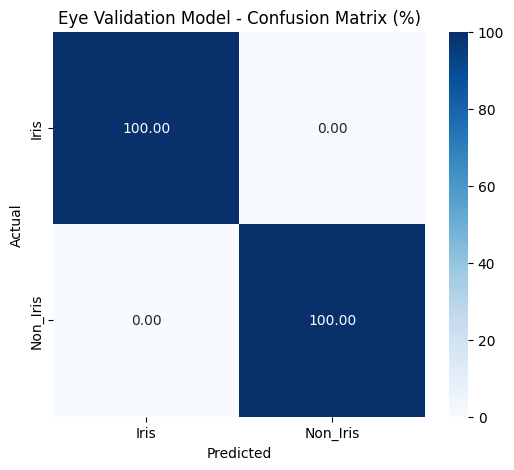

6/6 ━━━━━━━━━━━━━━━━━━━━ 54s 8s/step

Eye Health Classification Model
Accuracy  : 82.98%
Precision : 83.17%
Recall    : 82.98%
F1-score  : 82.92%


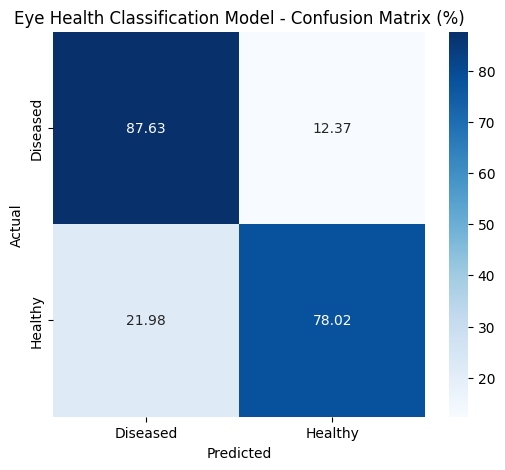

In [ ]:
#RUN EVALUATION (SEPARATE RESULTS)
evaluate_model(
    eye_validation_model,
    eye_val,
    EYE_CLASSES,
    "Eye Validation Model"
)

evaluate_model(
    eye_health_model,
    health_val,
    HEALTH_CLASSES,
    "Eye Health Classification Model"
)


Saving 1 (57).png to 1 (57).png


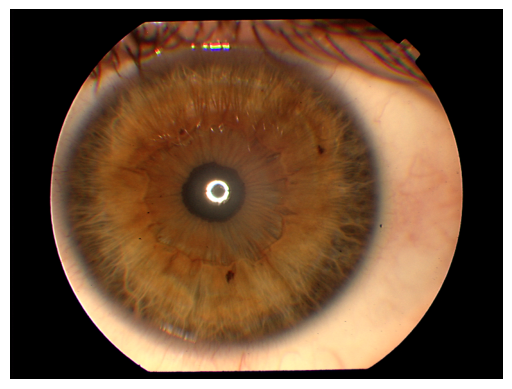

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Prediction: ⚠ Valid iris detected. Eye is DISEASED.


In [ ]:
#IMAGE UPLOAD + DISPLAY + PREDICTION
def predict_eye_and_health(image):
    image = image.convert("RGB")
    img = np.array(image.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    img = np.expand_dims(img, axis=0)

    eye_pred = eye_validation_model.predict(img)
    eye_class = np.argmax(eye_pred)

    if eye_class == 1:
        return "❌ Invalid iris image,Please upload a correct image"

    health_pred = eye_health_model.predict(img)
    health_class = np.argmax(health_pred)

    return "⚠ Valid iris detected. Eye is DISEASED." if health_class == 0 else "✅ Valid iris detected. No Abnormal Indicators Detected.Disease-related indicators for liver, spinal, and digestive conditions were not identified"


uploaded = files.upload()

for filename, filedata in uploaded.items():
    image = Image.open(io.BytesIO(filedata))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    result = predict_eye_and_health(image)
    print("Prediction:", result)


Saving 009L_2.png to 009L_2.png


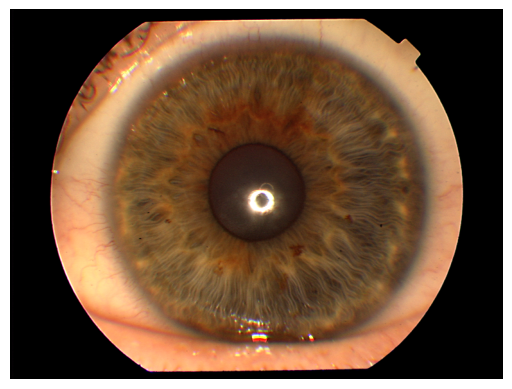

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
Prediction: ⚠ Valid iris detected. Eye is DISEASED.


In [ ]:
#IMAGE UPLOAD + DISPLAY + PREDICTION
def predict_eye_and_health(image):
    image = image.convert("RGB")
    img = np.array(image.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    img = np.expand_dims(img, axis=0)

    eye_pred = eye_validation_model.predict(img)
    eye_class = np.argmax(eye_pred)

    if eye_class == 1:
        return "❌ Invalid iris image,Please upload a correct image"

    health_pred = eye_health_model.predict(img)
    health_class = np.argmax(health_pred)

    return "⚠ Valid iris detected. Eye is DISEASED." if health_class == 0 else "✅ Valid iris detected. No Abnormal Indicators Detected.Disease-related indicators for liver, spinal, and digestive conditions were not identified"


uploaded = files.upload()

for filename, filedata in uploaded.items():
    image = Image.open(io.BytesIO(filedata))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    result = predict_eye_and_health(image)
    print("Prediction:", result)

Saving s0003_00287_0_0_0_0_0_01.png to s0003_00287_0_0_0_0_0_01.png


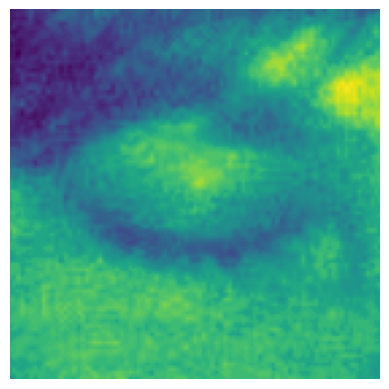

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Prediction: ❌ Invalid iris image,Please upload a correct image


In [ ]:
#IMAGE UPLOAD + DISPLAY + PREDICTION
def predict_eye_and_health(image):
    image = image.convert("RGB")
    img = np.array(image.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    img = np.expand_dims(img, axis=0)

    eye_pred = eye_validation_model.predict(img)
    eye_class = np.argmax(eye_pred)

    if eye_class == 1:
        return "❌ Invalid iris image,Please upload a correct image"

    health_pred = eye_health_model.predict(img)
    health_class = np.argmax(health_pred)

    return "⚠ Valid iris detected. Eye is DISEASED." if health_class == 0 else "✅ Valid iris detected. No Abnormal Indicators Detected.Disease-related indicators for liver, spinal, and digestive conditions were not identified"


uploaded = files.upload()

for filename, filedata in uploaded.items():
    image = Image.open(io.BytesIO(filedata))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    result = predict_eye_and_health(image)
    print("Prediction:", result)